In [1]:
!pip install praw pandas matplotlib 

In [2]:
import pandas as pd
import sys
import json
import string
from collections import Counter
import nltk
import re
import html
#for messy text in comments, helps removes non-lexicon data for cleaner analysis
from nltk.tokenize import TweetTokenizer
tokenizer = TweetTokenizer()

from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

nltk.download('stopwords')
import matplotlib.pyplot as mpl



[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/forsc1/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
#Function to pre-process reddit data

def processText(text, tokenizer, stemmer, stopwords):

    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    
    lTokens = tokenizer.tokenize(text)
    lTokens = [token.strip() for token in lTokens]

    lTokens = [
        tok for tok in lTokens
        if tok not in stopwords
        and not tok.isdigit()
        and len(tok) > 2
        and tok.isalpha()
    ]
    
    return lTokens

    

In [7]:
#doing tokenization stopword removal and stemming to furher clean the data

fJsonName = "rawComments.json"
dfComments = pd.read_json("rawComments.json")

#removing deleted and duplicated comments
dfComments = dfComments.dropna(subset=["body"])
dfComments = dfComments[~dfComments["body"].isin(["[deleted]", "[removed]"])]

wordFrequency = 50
customStopwords = [
    "would", "could", "should", "one", "get", "got", "say", "said","think", "know", "like", "also", "even", "really", "much",
    "make", "go", "going", "want", "people", "thing", "way", "time", "see", "need", "right", "well", "back", "still", "good", 
    "bad", "new", "old", "many", "every", "something"
]

lPunct = list(string.punctuation)
lStopwords = nltk.corpus.stopwords.words('english') + lPunct + ['via', 'http', 'https', 'www',] + customStopwords

wordFreqCounter = Counter()

cleanComments = []

for comment in dfComments["body"]:

    lTokens = processText(
        text=str(comment),
        stopwords=lStopwords,
        tokenizer=tokenizer,
        stemmer=stemmer,
    )

    wordFreqCounter.update(lTokens)

    cleanComment = " ".join(lTokens)
    cleanComments.append(cleanComment)

#adding cleaned column
dfComments["cleanBody"] = cleanComments

#saving cleaned data
dfComments.to_json("cleanComments.json", orient="records")

#printing the most common words to check pre-processing worked
for word, count in wordFreqCounter.most_common(wordFrequency):
    print(word + ': ' + str(count)) 


russia: 341
world: 266
government: 258
country: 247
police: 246
years: 245
actually: 223
money: 218
never: 211
point: 211
war: 208
things: 184
better: 178
state: 177
countries: 175
yes: 166
sure: 166
israel: 164
oil: 164
work: 160
lot: 157
believe: 155
made: 154
american: 153
year: 152
someone: 147
anything: 145
nothing: 143
mean: 142
military: 141
take: 140
change: 138
saying: 138
america: 138
use: 137
putin: 136
without: 135
look: 133
shit: 132
part: 130
two: 129
around: 129
less: 128
wrong: 128
public: 127
since: 127
pretty: 127
long: 127
everyone: 127
different: 125


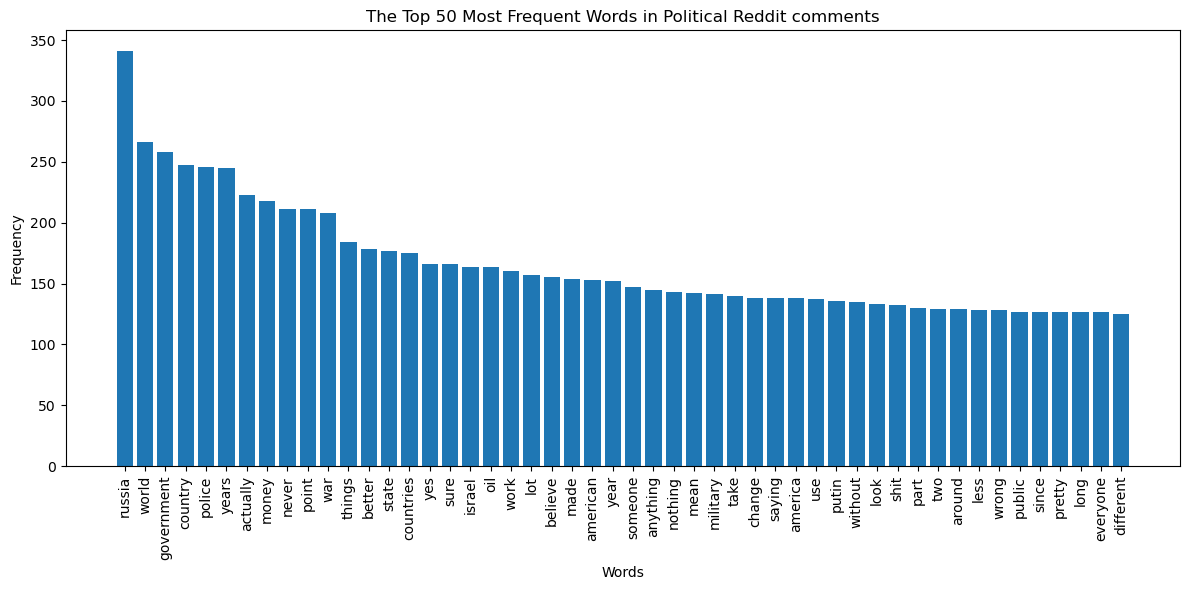

In [8]:
#Data graph for more frequent terms 
words = []
counts = []

for word, count in wordFreqCounter.most_common(wordFrequency):
    words.append(word)
    counts.append(count)

mpl.figure(figsize=(12, 6))
mpl.bar(words, counts)
mpl.xticks(rotation=90)
mpl.title("The Top 50 Most Frequent Words in Political Reddit comments")
mpl.xlabel("Words")
mpl.ylabel("Frequency")
mpl.tight_layout()
mpl.show()
